> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 04 朴素贝叶斯：贝叶斯推断、条件独立与概率分类

从贝叶斯公式出发，解释“朴素”假设如何简化联合概率，并完成 Gaussian Naive Bayes 的手写与 sklearn 实现。

## 模型简介与学习参考

朴素贝叶斯是一类生成式概率分类模型：它先估计每个类别的先验概率和类条件分布，再通过贝叶斯公式比较后验概率。所谓“朴素”，指给定类别后假设各特征条件独立。

| 项目 | 内容 |
|---|---|
| 模型定位 | 基于概率生成过程的监督分类模型 |
| 核心思想 | 先验 × 类条件似然 → 后验概率 |
| 典型任务 | 文本分类、垃圾邮件识别、连续特征分类 |
| 主要优点 | 训练快；小样本下稳定；可直接输出概率 |
| 主要限制 | 条件独立假设较强；概率质量依赖分布假设 |

**学习参考**

- 周志华《机器学习》（西瓜书）第 7 章：贝叶斯分类器。
- [南瓜书（Datawhale）](https://github.com/datawhalechina/pumpkin-book)：相关概率公式的补充推导。
- [scikit-learn Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)：官方模型变体与参数说明。
- [ML-From-Scratch](https://github.com/eriklindernoren/ML-From-Scratch)：参考从零实现的代码组织。

本章把概率推导、数值稳定技巧和实际调用整合在同一条学习链路中；正文与代码均按教学目的重新编排。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 条件概率与贝叶斯公式](#bayes-theorem)
  - [1.2 先验、似然、证据与后验](#bayes-terms)
  - [1.3 最大后验分类](#map)
  - [1.4 条件独立假设](#independence)
  - [1.5 Gaussian Naive Bayes](#gaussian)
  - [1.6 对数概率](#log-space)
  - [1.7 模型变体与平滑](#variants)
- [2. NumPy 手写朴素贝叶斯](#scratch)
  - [2.1 图形复现](#figure-code)
  - [2.2 数据准备](#scratch-data)
  - [2.3 模型实现](#scratch-model)
  - [2.4 训练评估](#scratch-evaluation)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 二维分类调用](#sklearn-basic)
  - [3.2 乳腺癌分类案例](#real-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="bayes-theorem"></a>
### 1.1 概率基础：条件概率与贝叶斯公式

对类别 (y) 和特征向量 (oldsymbol x)，条件概率定义为

$$
P(y\mid\boldsymbol x)=\frac{P(y,\boldsymbol x)}{P(\boldsymbol x)},
\qquad
P(\boldsymbol x\mid y)=\frac{P(y,\boldsymbol x)}{P(y)}.
$$

两式都包含联合概率 (P(y,\boldsymbol x))。由第二式得到

$$
P(y,\boldsymbol x)=P(\boldsymbol x\mid y)P(y),
$$

代回第一式：

$$
\boxed{
P(y\mid\boldsymbol x)
=\frac{P(\boldsymbol x\mid y)P(y)}{P(\boldsymbol x)}
}
$$

这就是贝叶斯公式。它解决的问题是：已知某类样本通常会产生怎样的特征，
观测到一个新样本后，应当怎样反推它属于各类别的概率。

<a id="bayes-terms"></a>
### 1.2 概率组成：先验、似然、证据与后验

| 名称 | 符号 | 含义 |
|---|---|---|
| 先验 | (P(y)) | 尚未观察当前样本时，类别本身出现的概率 |
| 似然 | (P(\boldsymbol x\mid y)) | 假设类别为 (y)，观察到这些特征的可能性 |
| 证据 | (P(\boldsymbol x)) | 当前特征在所有类别中的总概率 |
| 后验 | (P(y\mid\boldsymbol x)) | 观察特征后，样本属于类别 (y) 的概率 |

“先验 × 似然”得到未归一化后验，再除以证据使所有类别后验概率之和为 1。

<a id="map"></a>
### 1.3 分类决策：最大后验 MAP

分类只需要找到后验概率最大的类别：

$$
\hat y=\arg\max_k P(y=k\mid\boldsymbol x).
$$

对同一个待预测样本，证据 (P(\boldsymbol x)) 对所有类别完全相同，
因此在比较类别时可以约去：

$$
\hat y
=\arg\max_k
P(y=k)P(\boldsymbol x\mid y=k).
$$

这叫最大后验分类。先验体现类别原本有多常见，似然衡量当前特征与该类别有多匹配。

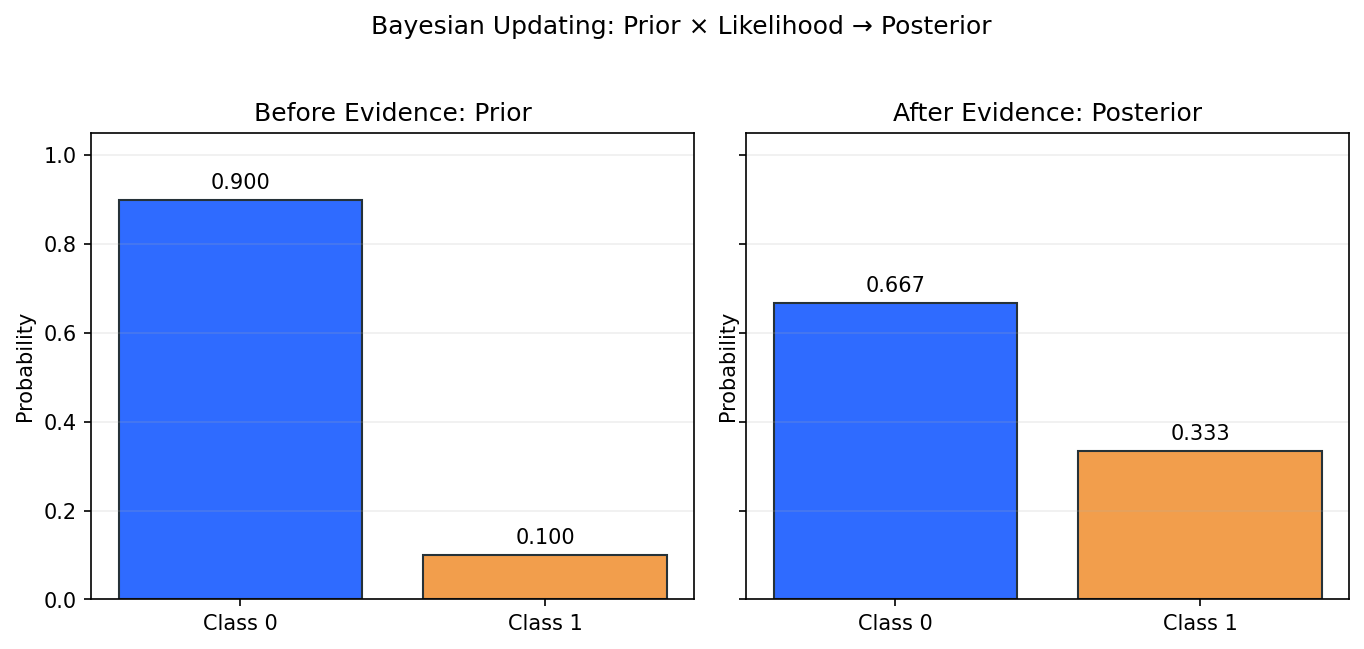

<a id="independence"></a>
### 1.4 朴素假设：类条件独立

直接估计高维联合似然 (P(x_1,\ldots,x_d\mid y)) 需要大量数据。
朴素贝叶斯作出关键假设：**给定类别以后，各个特征相互条件独立**。

$$
P(\boldsymbol x\mid y=k)
=P(x_1,\ldots,x_d\mid y=k)
\approx\prod_{j=1}^{d}P(x_j\mid y=k).
$$

于是分类规则变为

$$
\boxed{
\hat y=\arg\max_k P(y=k)\prod_{j=1}^{d}P(x_j\mid y=k)
}
$$

这个假设通常并不完全真实，但它把一个高维密度估计问题拆成多个一维问题，
因而训练快、需要的数据较少。代价是相关特征可能被重复计算，使预测概率过于自信。

下图中，倾斜椭圆表示特征存在相关性；朴素假设只保留每个特征自己的方差，
因而等高线与坐标轴平行。

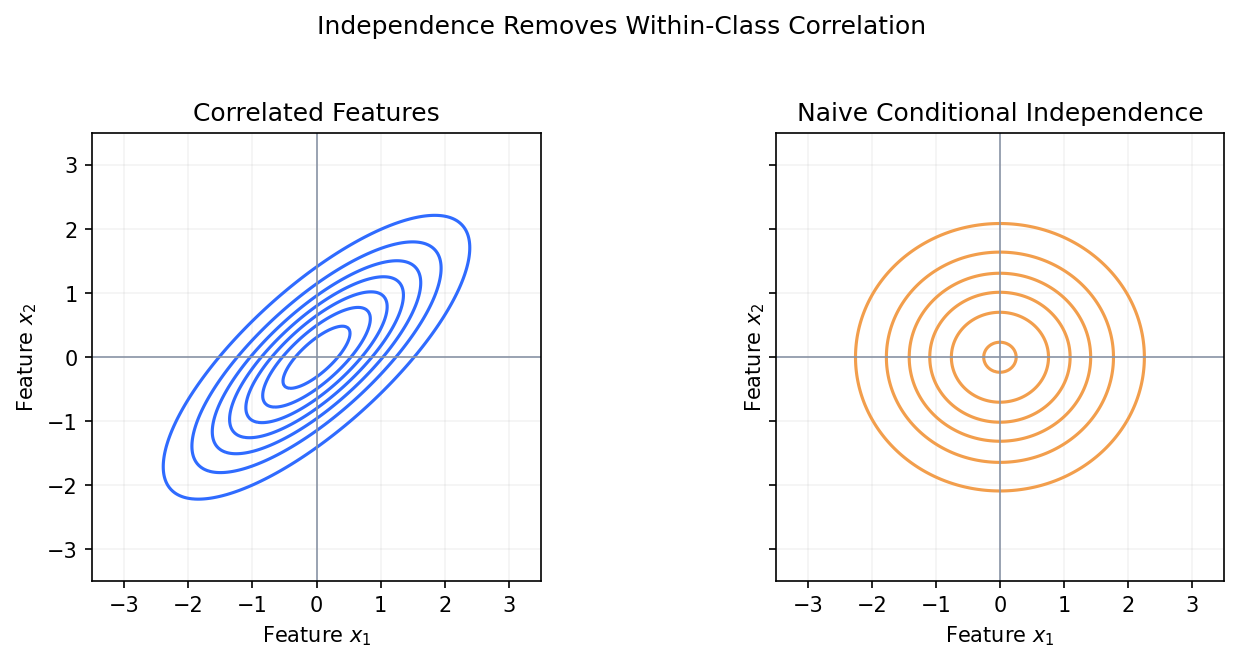

<a id="gaussian"></a>
### 1.5 连续特征：Gaussian Naive Bayes

当特征是连续数值时，Gaussian Naive Bayes 假设：在类别 (k) 内，
第 (j) 个特征服从一维高斯分布：

$$
P(x_j\mid y=k)
=\frac{1}{\sqrt{2\pi\sigma_{kj}^{2}}}
\exp\left[-\frac{(x_j-\mu_{kj})^2}{2\sigma_{kj}^{2}}\right].
$$

训练不需要梯度下降，只需对每个类别分别计算：

$$
\hat P(y=k)=\frac{n_k}{n},\qquad
\hat\mu_{kj}=\frac1{n_k}\sum_{i:y_i=k}x_{ij},
$$

$$
\hat\sigma_{kj}^{2}
=\frac1{n_k}\sum_{i:y_i=k}(x_{ij}-\hat\mu_{kj})^2.
$$

预测时，每个类别得到“先验 × 各特征高斯似然”的分数，分数最大的类别获胜。
所以本模型没有梯度下降 Loss 曲线；参数在一次统计中直接估计完成。

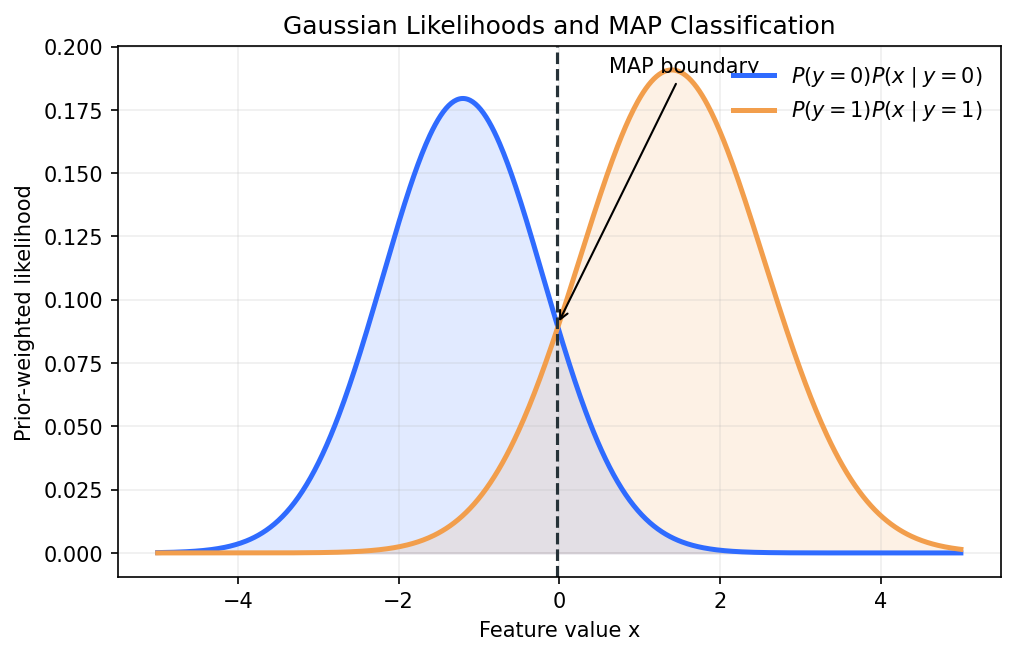

<a id="log-space"></a>
### 1.6 数值稳定：对数概率

多个小概率连续相乘可能下溢为 0。对数把乘法变成加法，而且不改变最大值的位置：

$$
g_k(\boldsymbol x)
=\log P(y=k)
+\sum_{j=1}^{d}\log P(x_j\mid y=k).
$$

代入高斯密度：

$$
g_k(\boldsymbol x)
=\log P(y=k)
-\frac12\sum_{j=1}^{d}
\left[
\log(2\pi\sigma_{kj}^2)
+\frac{(x_j-\mu_{kj})^2}{\sigma_{kj}^2}
\right].
$$

若某个特征在某类中的方差接近 0，分母会导致数值不稳定。
因此实现时给所有方差加入很小的平滑量：

$$
\tilde\sigma_{kj}^2=\hat\sigma_{kj}^2+\epsilon.
$$

这里的方差平滑用于数值稳定，与离散朴素贝叶斯的拉普拉斯计数平滑作用不同。

<a id="variants"></a>
### 1.7 模型变体：分布假设与拉普拉斯平滑

| 模型 | 特征假设 | 常见用途 |
|---|---|---|
| `GaussianNB` | 连续特征在每个类别内近似高斯分布 | 测量值、医学指标、传感器数据 |
| `MultinomialNB` | 非负计数或频率 | 词频、文本分类 |
| `BernoulliNB` | 二值特征是否出现 | 词是否出现、0/1 属性 |

在 MultinomialNB 或 BernoulliNB 中，如果某个词从未在某类出现，直接估计会得到概率 0，
进而让整项乘积变为 0。加入 α 的平滑估计为

$$
\hat\theta_{kj}=\frac{N_{kj}+\alpha}{N_k+\alpha d}.
$$

α=1 称为拉普拉斯平滑。GaussianNB 估计的是均值和方差，不使用这个计数公式。

<a id="scratch"></a>
## 2. NumPy 手写朴素贝叶斯

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

以下三段代码与原理部分的三张嵌入图一一对应。

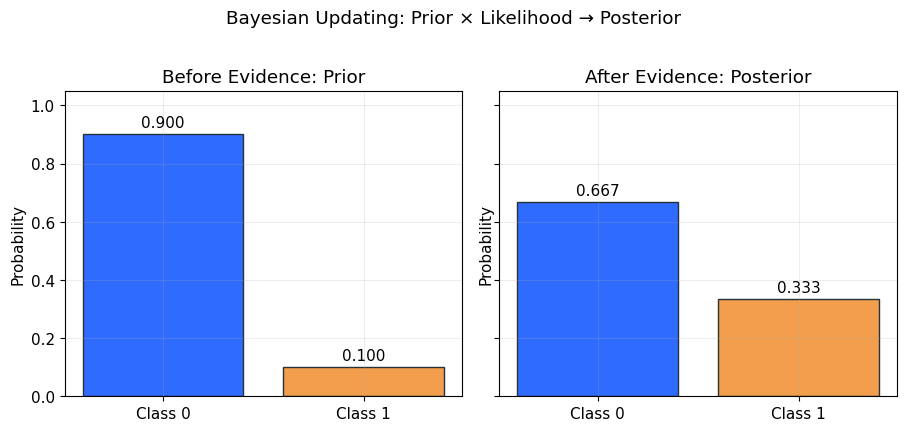

In [1]:
# 复现图 1：先验与后验
import json
import numpy as np
import matplotlib.pyplot as plt

BLUE = "#2F6BFF"
ORANGE = "#F29E4C"
DARK = "#263238"
GREY = "#8A94A6"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.22, "font.size": 11})

prior = np.array([0.90, 0.10])
likelihood = np.array([0.20, 0.90])
posterior = prior * likelihood
posterior /= posterior.sum()

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2), sharey=True)
labels = ["Class 0", "Class 1"]
colors = [BLUE, ORANGE]
axes[0].bar(labels, prior, color=colors, edgecolor=DARK)
axes[0].set_title("Before Evidence: Prior")
axes[1].bar(labels, posterior, color=colors, edgecolor=DARK)
axes[1].set_title("After Evidence: Posterior")
for ax, values in zip(axes, [prior, posterior]):
    for index, value in enumerate(values):
        ax.text(index, value + 0.025, f"{value:.3f}", ha="center")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
fig.suptitle("Bayesian Updating: Prior × Likelihood → Posterior", y=1.02)
plt.tight_layout()
plt.show()

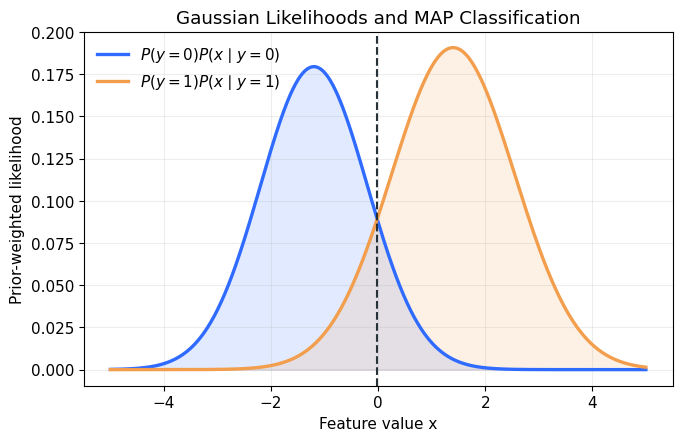

In [2]:
# 复现图 2：高斯似然与分类
x_grid = np.linspace(-5, 5, 600)

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (np.sqrt(2 * np.pi) * std)

weighted_0 = 0.45 * normal_pdf(x_grid, -1.2, 1.0)
weighted_1 = 0.55 * normal_pdf(x_grid, 1.4, 1.15)
crossing_candidates = np.where(np.diff(np.sign(weighted_0 - weighted_1)) != 0)[0]
midpoint = (-1.2 + 1.4) / 2
crossing_index = crossing_candidates[
    np.argmin(np.abs(x_grid[crossing_candidates] - midpoint))
]
crossing = x_grid[crossing_index]

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(x_grid, weighted_0, color=BLUE, linewidth=2.4, label=r"$P(y=0)P(x\mid y=0)$")
ax.plot(x_grid, weighted_1, color=ORANGE, linewidth=2.4, label=r"$P(y=1)P(x\mid y=1)$")
ax.fill_between(x_grid, weighted_0, alpha=0.14, color=BLUE)
ax.fill_between(x_grid, weighted_1, alpha=0.14, color=ORANGE)
ax.axvline(crossing, color=DARK, linestyle="--", linewidth=1.5)
ax.set(xlabel="Feature value x", ylabel="Prior-weighted likelihood",
       title="Gaussian Likelihoods and MAP Classification")
ax.legend(frameon=False)
plt.show()

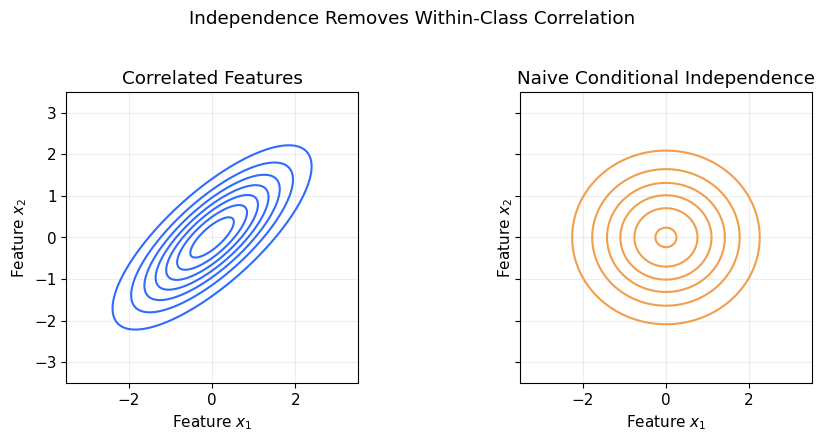

In [3]:
# 复现图 3：条件独立与等高线
def bivariate_density(x1, x2, mean, covariance):
    positions = np.stack([x1 - mean[0], x2 - mean[1]], axis=-1)
    inverse = np.linalg.inv(covariance)
    exponent = np.einsum("...i,ij,...j->...", positions, inverse, positions)
    normalizer = 2 * np.pi * np.sqrt(np.linalg.det(covariance))
    return np.exp(-0.5 * exponent) / normalizer

contour_x1, contour_x2 = np.meshgrid(
    np.linspace(-3.5, 3.5, 240), np.linspace(-3.5, 3.5, 240)
)
contour_mean = np.array([0.0, 0.0])
correlated_covariance = np.array([[1.4, 1.0], [1.0, 1.2]])
independent_covariance = np.diag(np.diag(correlated_covariance))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3), sharex=True, sharey=True)
axes[0].contour(
    contour_x1, contour_x2,
    bivariate_density(contour_x1, contour_x2, contour_mean, correlated_covariance),
    levels=7, colors=BLUE,
)
axes[0].set_title("Correlated Features")
axes[1].contour(
    contour_x1, contour_x2,
    bivariate_density(contour_x1, contour_x2, contour_mean, independent_covariance),
    levels=7, colors=ORANGE,
)
axes[1].set_title("Naive Conditional Independence")
for ax in axes:
    ax.set(xlabel=r"Feature $x_1$", ylabel=r"Feature $x_2$", aspect="equal")
fig.suptitle("Independence Removes Within-Class Correlation", y=1.02)
plt.tight_layout()
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：二维高斯模拟数据

手写部分使用 NumPy 从两个二维高斯分布生成数据。模型参数和随机种子全部可见，
不需要下载外部文件。这里只调用 sklearn 进行数据划分和指标计算；GaussianNB 的训练、
后验概率和预测均由后面的 NumPy 类完成。

In [4]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

random_generator = np.random.default_rng(42)
class_0 = random_generator.multivariate_normal(
    mean=[-1.45, -1.10],
    cov=[[1.0, 0.10], [0.10, 0.80]],
    size=240,
)
class_1 = random_generator.multivariate_normal(
    mean=[1.35, 1.20],
    cov=[[0.90, -0.12], [-0.12, 1.05]],
    size=240,
)
manual_X = np.vstack([class_0, class_1])
manual_y = np.r_[np.zeros(len(class_0), dtype=int), np.ones(len(class_1), dtype=int)]
manual_X_train, manual_X_test, manual_y_train, manual_y_test = train_test_split(
    manual_X,
    manual_y,
    test_size=0.25,
    stratify=manual_y,
    random_state=42,
)

def evaluate_binary(y_true, y_prediction, probability_positive):
    return {
        "Accuracy": accuracy_score(y_true, y_prediction),
        "Precision": precision_score(y_true, y_prediction),
        "Recall": recall_score(y_true, y_prediction),
        "F1": f1_score(y_true, y_prediction),
        "ROC-AUC": roc_auc_score(y_true, probability_positive),
    }

def plot_probability_boundary(model, X, y, title):
    margin = 0.8
    x1_min, x1_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x2_min, x2_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    grid_x1, grid_x2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 260),
        np.linspace(x2_min, x2_max, 260),
    )
    grid = np.c_[grid_x1.ravel(), grid_x2.ravel()]
    grid_probability = model.predict_proba(grid)[:, 1].reshape(grid_x1.shape)

    fig, ax = plt.subplots(figsize=(7.0, 5.2))
    filled = ax.contourf(
        grid_x1, grid_x2, grid_probability,
        levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.58,
    )
    boundary = ax.contour(
        grid_x1, grid_x2, grid_probability,
        levels=[0.5], colors=DARK, linewidths=2,
    )
    ax.clabel(boundary, fmt={0.5: "p=0.5"})
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="white", s=34, alpha=0.86)
    fig.colorbar(filled, ax=ax, label="P(y=1|x)")
    ax.set(xlabel="Feature 1", ylabel="Feature 2", title=title)
    plt.tight_layout()
    plt.show()

def plot_binary_evaluation(y_true, y_prediction, probability_positive, title, class_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, probability_positive)
    auc_value = roc_auc_score(y_true, probability_positive)
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_prediction,
        display_labels=class_names,
        cmap="Blues",
        colorbar=False,
        ax=axes[0],
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].grid(False)
    axes[1].plot(false_positive_rate, true_positive_rate, color=BLUE,
                 linewidth=2.2, label=f"GaussianNB (AUC={auc_value:.3f})")
    axes[1].plot([0, 1], [0, 1], "--", color=GREY, label="Random classifier")
    axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
    axes[1].legend(loc="lower right", frameon=False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

<a id="scratch-model"></a>
### 2.3 模型实现：`GaussianNaiveBayesScratch`

`fit` 统计先验、均值和方差；`_joint_log_posterior` 按推导式计算每类得分；
`predict_proba` 先减去每行最大得分，再指数化和归一化，避免数值上溢或下溢。

In [5]:
class GaussianNaiveBayesScratch:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_, class_counts = np.unique(y, return_counts=True)
        self.class_log_prior_ = np.log(class_counts / len(y))
        self.theta_ = np.vstack([X[y == label].mean(axis=0) for label in self.classes_])
        self.var_ = np.vstack([X[y == label].var(axis=0) for label in self.classes_])
        self.epsilon_ = self.var_smoothing * np.var(X, axis=0).max()
        self.var_ += self.epsilon_
        return self

    def _joint_log_posterior(self, X):
        X = np.atleast_2d(np.asarray(X, dtype=float))
        scores = []
        for class_index in range(len(self.classes_)):
            mean = self.theta_[class_index]
            variance = self.var_[class_index]
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * variance) + (X - mean) ** 2 / variance,
                axis=1,
            )
            scores.append(self.class_log_prior_[class_index] + log_likelihood)
        return np.column_stack(scores)

    def predict_proba(self, X):
        log_scores = self._joint_log_posterior(X)
        shifted_scores = log_scores - log_scores.max(axis=1, keepdims=True)
        unnormalized = np.exp(shifted_scores)
        return unnormalized / unnormalized.sum(axis=1, keepdims=True)

    def predict(self, X):
        probability = self.predict_proba(X)
        return self.classes_[np.argmax(probability, axis=1)]

<a id="scratch-evaluation"></a>
### 2.4 训练评估：边界、矩阵与 ROC

朴素贝叶斯训练没有迭代过程，因此这里不画 Loss。完整验证包括概率范围、
分类指标、概率决策边界、混淆矩阵和 ROC。

In [6]:
manual_model = GaussianNaiveBayesScratch().fit(manual_X_train, manual_y_train)
manual_probability = manual_model.predict_proba(manual_X_test)
manual_prediction = manual_model.predict(manual_X_test)
manual_metrics = evaluate_binary(manual_y_test, manual_prediction, manual_probability[:, 1])

print("手写模型验证通过")
print("Class priors:", np.exp(manual_model.class_log_prior_))
print("Means:\n", np.round(manual_model.theta_, 3))
print("Variances:\n", np.round(manual_model.var_, 3))
for metric_name, metric_value in manual_metrics.items():
    print(f"{metric_name:9s}: {metric_value:.4f}")

手写模型验证通过
Class priors: [0.5 0.5]
Means:
 [[-1.502 -1.148]
 [ 1.413  1.058]]
Variances:
 [[0.973 0.676]
 [0.737 1.286]]
Accuracy : 0.9333
Precision: 0.9194
Recall   : 0.9500
F1       : 0.9344
ROC-AUC  : 0.9856


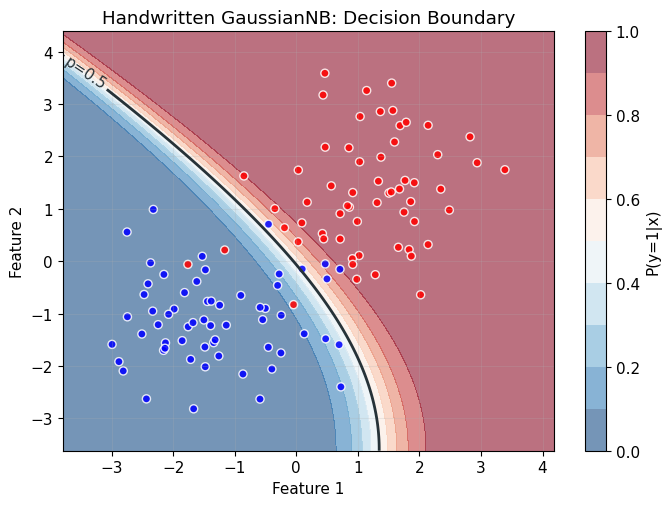

In [7]:
plot_probability_boundary(
    manual_model,
    manual_X_test,
    manual_y_test,
    "Handwritten GaussianNB: Decision Boundary",
)

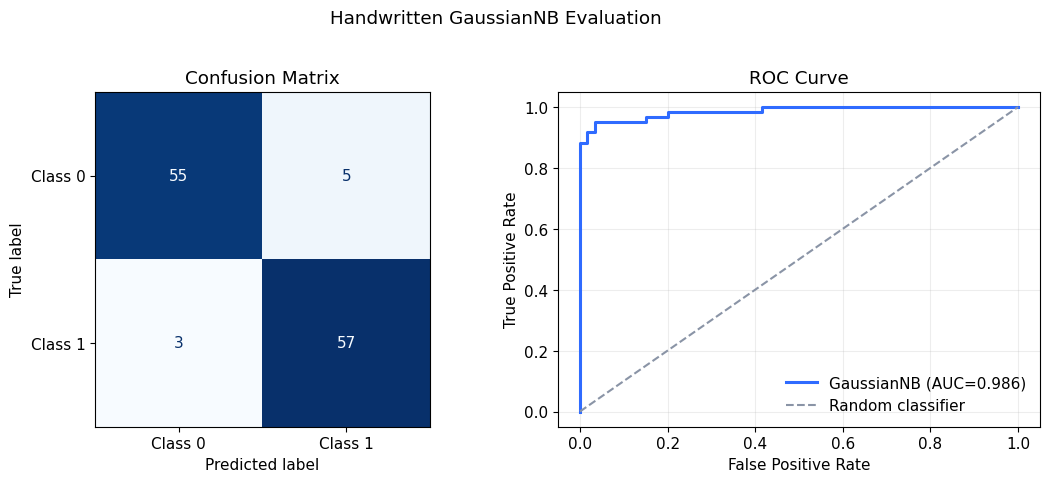

In [8]:
plot_binary_evaluation(
    manual_y_test,
    manual_prediction,
    manual_probability[:, 1],
    "Handwritten GaussianNB Evaluation",
    ["Class 0", "Class 1"],
)

手写模型只通过样本统计量完成训练。决策边界通常是曲线，因为两个类别可以拥有不同的均值和方差；
混淆矩阵展示固定阈值下的错误数量，ROC-AUC 则综合评价不同阈值下的区分能力。

<a id="sklearn"></a>
## 3. sklearn 调用与案例

统一流程：导入 → 数据划分 → `GaussianNB.fit` → 预测 → 指标 → 评估图 → 简短结论。

<a id="sklearn-basic"></a>
### 3.1 分类调用：二维 GaussianNB

基础示例使用二维数据，既展示 sklearn 的最小调用，也保留概率边界、混淆矩阵和 ROC。

In [9]:
from sklearn.datasets import load_breast_cancer, make_classification
from IPython.display import HTML, display
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))

basic_X, basic_y = make_classification(
    n_samples=420,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.45,
    random_state=42,
)
basic_X_train, basic_X_test, basic_y_train, basic_y_test = train_test_split(
    basic_X,
    basic_y,
    test_size=0.25,
    stratify=basic_y,
    random_state=42,
)
basic_model = GaussianNB().fit(basic_X_train, basic_y_train)
basic_probability = basic_model.predict_proba(basic_X_test)[:, 1]
basic_prediction = basic_model.predict(basic_X_test)
basic_metrics = evaluate_binary(basic_y_test, basic_prediction, basic_probability)

print("基础示例")
for metric_name, metric_value in basic_metrics.items():
    print(f"{metric_name:9s}: {metric_value:.4f}")

基础示例
Accuracy : 0.9524
Precision: 0.9796
Recall   : 0.9231
F1       : 0.9505
ROC-AUC  : 0.9837


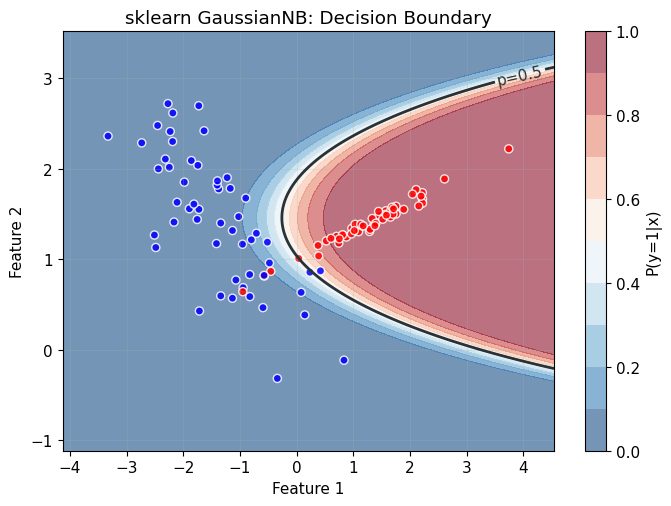

In [10]:
plot_probability_boundary(
    basic_model,
    basic_X_test,
    basic_y_test,
    "sklearn GaussianNB: Decision Boundary",
)

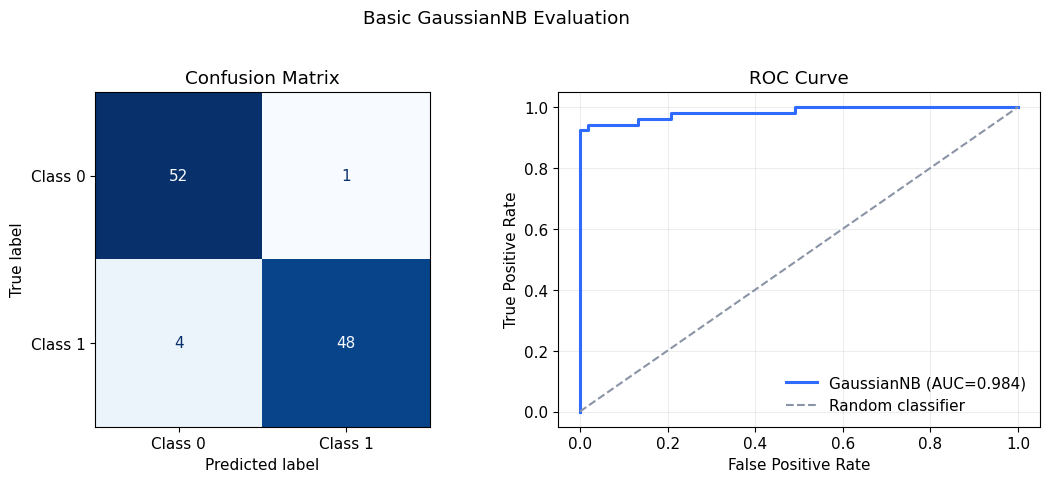

In [11]:
plot_binary_evaluation(
    basic_y_test,
    basic_prediction,
    basic_probability,
    "Basic GaussianNB Evaluation",
    ["Class 0", "Class 1"],
)

二维概率背景展示 GaussianNB 如何根据每类的均值和方差形成非线性边界；
指标图分别检查固定阈值的错误和全部阈值下的排序能力。

<a id="real-case"></a>
### 3.2 分类案例：乳腺癌良恶性诊断

`load_breast_cancer` 包含 569 个样本和 30 个由细胞核图像提取的连续特征。
标签 0 表示恶性，标签 1 表示良性。这里将良性 1 作为正类，与逻辑回归章节保持一致。
30 维完整模型的真实边界不能直接画在二维平面，因此完整指标、混淆矩阵和 ROC
仍由全部特征模型给出；另外训练一个 **PCA 二维投影模型**显示近似边界，仅用于可视化。
因此它应读作：**PCA 二维投影边界（仅用于可视化）**。

In [12]:
cancer = load_breast_cancer()
real_X_train, real_X_test, real_y_train, real_y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.20,
    stratify=cancer.target,
    random_state=42,
)
real_model = make_pipeline(StandardScaler(), GaussianNB())
real_model.fit(real_X_train, real_y_train)
real_probability = real_model.predict_proba(real_X_test)[:, 1]
real_prediction = real_model.predict(real_X_test)
real_metrics = evaluate_binary(real_y_test, real_prediction, real_probability)

print("真实场景：乳腺肿瘤良恶性分类")
print(f"Samples: {cancer.data.shape[0]}; features: {cancer.data.shape[1]}")
for metric_name, metric_value in real_metrics.items():
    print(f"{metric_name:9s}: {metric_value:.4f}")

display_result_table(
    "乳腺癌 GaussianNB 真实案例指标表",
    ["指标", "数值", "含义"],
    [
        ["Accuracy", f'{real_metrics["Accuracy"]:.3f}', "总体预测正确率"],
        ["Precision", f'{real_metrics["Precision"]:.3f}', "预测为正类时的准确程度"],
        ["Recall", f'{real_metrics["Recall"]:.3f}', "实际正类被识别的比例"],
        ["F1", f'{real_metrics["F1"]:.3f}', "Precision 与 Recall 的调和平均"],
        ["ROC-AUC", f'{real_metrics["ROC-AUC"]:.3f}', "全部阈值下的排序能力"],
    ],
)

真实场景：乳腺肿瘤良恶性分类
Samples: 569; features: 30
Accuracy : 0.9298
Precision: 0.9444
Recall   : 0.9444
F1       : 0.9444
ROC-AUC  : 0.9868


指标,数值,含义
Accuracy,0.930,总体预测正确率
Precision,0.944,预测为正类时的准确程度
Recall,0.944,实际正类被识别的比例
F1,0.944,Precision 与 Recall 的调和平均
ROC-AUC,0.987,全部阈值下的排序能力


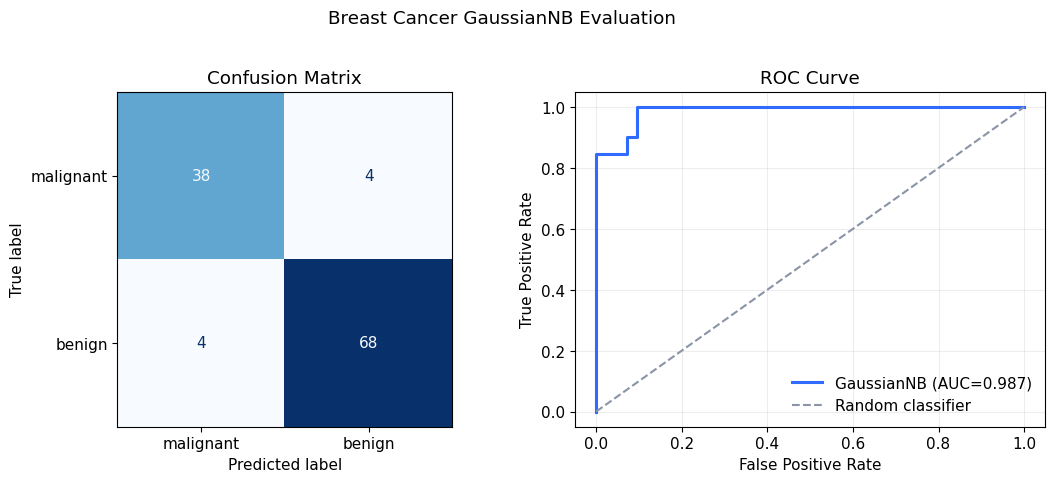

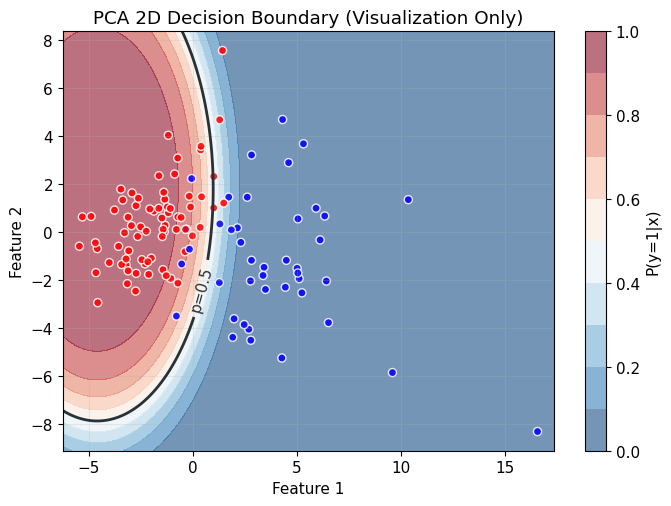

In [13]:
plot_binary_evaluation(
    real_y_test,
    real_prediction,
    real_probability,
    "Breast Cancer GaussianNB Evaluation",
    cancer.target_names,
)

real_visual_scaler = StandardScaler()
real_X_train_scaled = real_visual_scaler.fit_transform(real_X_train)
real_X_test_scaled = real_visual_scaler.transform(real_X_test)
real_visual_pca = PCA(n_components=2, random_state=42)
real_X_train_pca = real_visual_pca.fit_transform(real_X_train_scaled)
real_X_test_pca = real_visual_pca.transform(real_X_test_scaled)
real_visual_model = GaussianNB().fit(real_X_train_pca, real_y_train)
plot_probability_boundary(
    real_visual_model,
    real_X_test_pca,
    real_y_test,
    "PCA 2D Decision Boundary (Visualization Only)",
)

GaussianNB 训练速度快，并能直接输出类别概率。但乳腺癌特征之间存在相关性，
条件独立假设可能使概率过于自信，因此概率值应结合 ROC-AUC、混淆矩阵和业务阈值一起解释。

<a id="summary"></a>
## 4. 章节小结

- 朴素贝叶斯通过贝叶斯公式把先验知识与观测证据结合为后验概率。
- 条件独立假设把高维联合似然拆成一维似然之积，使模型能用较少数据快速训练。
- GaussianNB 用类内高斯分布处理连续特征；实际计算采用对数概率避免数值下溢。
- 分类评估不能只看 Accuracy，还要结合混淆矩阵、Precision、Recall、F1 与 ROC-AUC。

In [14]:
probability_row_sum_error = float(
    np.max(np.abs(manual_probability.sum(axis=1) - 1.0))
)
validation = {
    "manual_accuracy": float(manual_metrics["Accuracy"]),
    "basic_accuracy": float(basic_metrics["Accuracy"]),
    "real_accuracy": float(real_metrics["Accuracy"]),
    "real_roc_auc": float(real_metrics["ROC-AUC"]),
    "probability_min": float(manual_probability.min()),
    "probability_max": float(manual_probability.max()),
    "probability_row_sum_error": probability_row_sum_error,
    "image_count": 9,
}

assert np.all(np.isfinite(list(validation.values())))
assert 0.0 <= manual_probability.min() <= manual_probability.max() <= 1.0
assert probability_row_sum_error < 1e-12
assert manual_metrics["Accuracy"] >= 0.85
assert basic_metrics["Accuracy"] >= 0.85
assert real_metrics["Accuracy"] >= 0.85

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写 GaussianNB Accuracy", f'{validation["manual_accuracy"]:.3f}', "通过"],
        ["基础 sklearn Accuracy", f'{validation["basic_accuracy"]:.3f}', "通过"],
        ["乳腺癌 Accuracy", f'{validation["real_accuracy"]:.3f}', "通过"],
        ["乳腺癌 ROC-AUC", f'{validation["real_roc_auc"]:.3f}', "通过"],
        ["概率行和误差", f'{validation["probability_row_sum_error"]:.2e}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写 GaussianNB Accuracy,0.933,通过
基础 sklearn Accuracy,0.952,通过
乳腺癌 Accuracy,0.930,通过
乳腺癌 ROC-AUC,0.987,通过
概率行和误差,2.22e-16,通过
已执行图表输出,9,通过
